In [22]:
import DiffLogicMnist as dfm

In [23]:
batch_size = 256 # this can be tuned as well

train_dataset = dfm.mnist_dataset.MNIST('./data-mnist', train=True, download=True, remove_border=True)
test_dataset = dfm.mnist_dataset.MNIST('./data-mnist', train=False, remove_border=True)

train_loader = dfm.DataLoader(train_dataset, batch_size=batch_size, shuffle=True, pin_memory=True, drop_last=True)
test_loader = dfm.DataLoader(test_dataset, batch_size=batch_size, shuffle=False, pin_memory=True, drop_last=True)

#### Training

In [24]:
model_name = 'model_20x20'

# Initialize Hydra with the config path and job name
with dfm.initialize(version_base=None, config_path="config", job_name="test_app"):
    # Compose the configuration by specifying the config name
    cfg = dfm.compose(config_name="mnist_config")

# Access the configuration for a specific model (e.g., model_001)
model_cfg = cfg.models[model_name]
print(model_cfg)

{'input_dim': 400, 'layers_config': {'LogicLayer001': {'connections': 'random', 'device': 'cuda', 'grad_factor': 1, 'implementation': 'cuda', 'in_dim': 400, 'out_dim': 1000}, 'LogicLayer002': {'connections': 'random', 'device': 'cuda', 'grad_factor': 1, 'implementation': 'cuda', 'in_dim': 1000, 'out_dim': 1000}, 'LogicLayer003': {'connections': 'random', 'device': 'cuda', 'grad_factor': 1, 'implementation': 'cuda', 'in_dim': 1000, 'out_dim': 1000}, 'LogicLayer004': {'connections': 'random', 'device': 'cuda', 'grad_factor': 1, 'implementation': 'cuda', 'in_dim': 1000, 'out_dim': 1000}, 'LogicLayer005': {'connections': 'random', 'device': 'cuda', 'grad_factor': 1, 'implementation': 'cuda', 'in_dim': 1000, 'out_dim': 1000}}, 'learning_rate': 0.01, 'output_size': 10, 'tau': 30}


In [25]:
model = dfm.Model(model_cfg).to('cuda')

# Initialize EarlyStopper with a patience of 10 epochs
early_stopper = dfm.EarlyStopper(patience=10)

num_epochs = 100
losses = []

for epoch in range(num_epochs):
    loop = dfm.tqdm(train_loader, leave=True, desc=f'Epoch {epoch+1}/{num_epochs}')
    epoch_loss = 0  # Track loss for the entire epoch
    
    for batch_inputs, batch_outputs in loop:
        # Move to GPU if available
        batch_inputs, batch_outputs = batch_inputs.to('cuda').double(), batch_outputs.to('cuda').long()
        
        # Create prediction dictionary
        prediction_dict = {
            "input_data": batch_inputs, 
            "true_output_data": batch_outputs
        }
                
        # Forward pass
        model.forward(prediction_dict)
        
        # Compute the loss
        loss = model.test_train(prediction_dict)
        
        # Zero gradients, backpropagate, and update the model parameters
        model.optimizer.zero_grad()
        loss.backward()
        model.step()

        # Accumulate the batch loss
        epoch_loss += loss.item()
    
    # Calculate the average loss for the epoch
    epoch_loss /= len(train_loader)
    losses.append(epoch_loss)
    print(f'Epoch {epoch+1} Loss: {epoch_loss}')

    # Check if we should stop early
    if early_stopper.should_stop(epoch_loss):
        print(f"Early stopping triggered at epoch {epoch+1}. Training stopped.")
        break

# Save the model after training completes
FILE_PATH = 'trained_models'
FILE_NAME = f'{model_name}_weights'
model.save(FILE_PATH, FILE_NAME)

LogicLayer(400, 1000, train)
LogicLayer(1000, 1000, train)
LogicLayer(1000, 1000, train)
LogicLayer(1000, 1000, train)
LogicLayer(1000, 1000, train)


Epoch 1/100: 100%|██████████| 234/234 [00:18<00:00, 12.36it/s]


Epoch 1 Loss: 2.18734101740899


Epoch 2/100: 100%|██████████| 234/234 [00:11<00:00, 20.80it/s]


Epoch 2 Loss: 1.6189709155224319


...

Epoch 98 Loss: 1.3588082480177992
EarlyStopper Triggered:  2


Epoch 99/100: 100%|██████████| 234/234 [00:11<00:00, 20.23it/s]


Epoch 99 Loss: 1.3587570406095866
EarlyStopper Triggered:  3


Epoch 100/100: 100%|██████████| 234/234 [00:11<00:00, 20.23it/s]


Epoch 100 Loss: 1.358561857338321


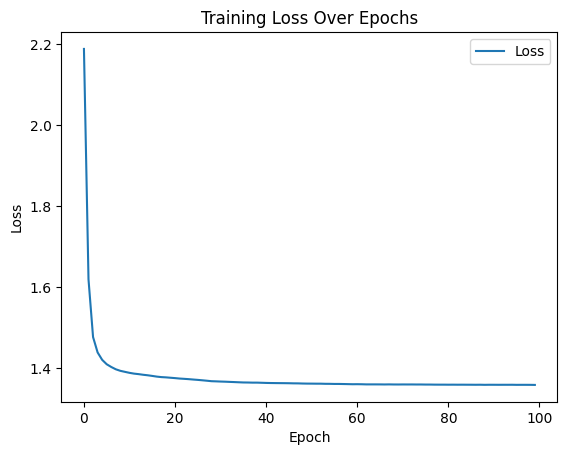

Running Inference: 100%|██████████| 39/39 [00:05<00:00,  7.35it/s]


0.8197115384615384

In [26]:
model.plot_loss(losses)
model.get_accuracy(test_loader)

#### Inference

In [19]:
model_name = 'model_107'
model_name_config = model_name # from mnist_config.yaml
model_name_weights = f'{model_name}_weights' # trained weights in model_name.pth
trained_models_dir = 'trained_models'
PATH = f'{trained_models_dir}/{model_name_weights}.pth'

# ensure you have a "mnist_config.yaml" file within a "config" folder
with dfm.initialize(version_base=None, config_path="config", job_name="test_app"):
    cfg = dfm.compose(config_name="mnist_config")

# access the configuration for a specific model (e.g., model_000)
model_cfg = cfg['models'][model_name_config]

# instantiate the model and load its weights
model = dfm.Model(model_cfg).to('cuda')
model.load(PATH)

model.get_accuracy(test_loader)

LogicLayer(784, 10000, train)
LogicLayer(10000, 10000, train)
LogicLayer(10000, 10000, train)
LogicLayer(10000, 10000, train)
LogicLayer(10000, 10000, train)


Running Inference: 100%|██████████| 39/39 [00:00<00:00, 68.35it/s]


0.960136217948718